In [1]:
pip install opencv-contrib-python scikit-image pywavelets matplotlib pandas scikit-learn

In [2]:
!pip install keras-facenet

In [3]:
import cv2
import os
import numpy as np
import pywt
import pandas as pd
import matplotlib.pyplot as plt
from keras_facenet import FaceNet
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!ls "/content/drive/MyDrive/DIP Dataset 1 FEI"

originalimages_part1  originalimages_part3
originalimages_part2  originalimages_part4


In [7]:
import cv2
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/DIP Dataset 1 FEI"

images = []
labels = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        gray = cv2.resize(gray, (100,100))

        label = int(img_name.split("-")[0])

        images.append(gray)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Total images loaded:", len(images))
print("Total labels:", len(labels))

Total images loaded: 2800
Total labels: 2800


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.5,
    stratify=labels,
    random_state=42
)

In [9]:
def compute_metrics(preds):

    acc = accuracy_score(y_test,preds)*100
    prec = precision_score(y_test,preds,average='macro')*100
    rec = recall_score(y_test,preds,average='macro')*100
    f1 = f1_score(y_test,preds,average='macro')*100

    return acc,prec,rec,f1

In [10]:
def image_quality(original, processed):

    original = original.astype(np.uint8)
    processed = processed.astype(np.uint8)

    p = psnr(original, processed, data_range=255)

    s, _ = ssim(original, processed, full=True, data_range=255)

    return p, s

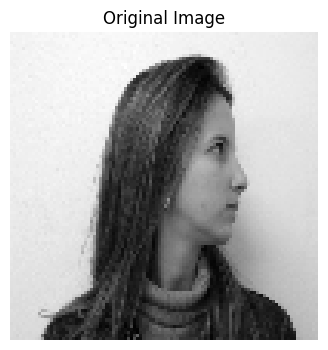

In [11]:
import matplotlib.pyplot as plt

sample = images[0]

plt.figure(figsize=(4,4))
plt.imshow(sample, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [12]:
def median_filter(img):
    return cv2.medianBlur(img,3)

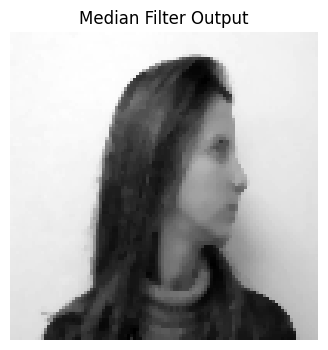

In [13]:
median_img = median_filter(sample)

plt.figure(figsize=(4,4))
plt.imshow(median_img, cmap='gray')
plt.title("Median Filter Output")
plt.axis("off")
plt.show()

In [14]:
def gray_normalization(img):

    norm = cv2.normalize(img,None,0,255,cv2.NORM_MINMAX)

    return norm

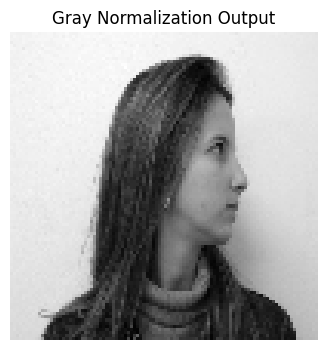

In [15]:
graynorm_img = gray_normalization(sample)

plt.figure(figsize=(4,4))
plt.imshow(graynorm_img, cmap='gray')
plt.title("Gray Normalization Output")
plt.axis("off")
plt.show()

In [16]:
def geometric_norm(img):

    rows,cols = img.shape

    M = cv2.getRotationMatrix2D((cols/2,rows/2),5,1)

    return cv2.warpAffine(img,M,(cols,rows))

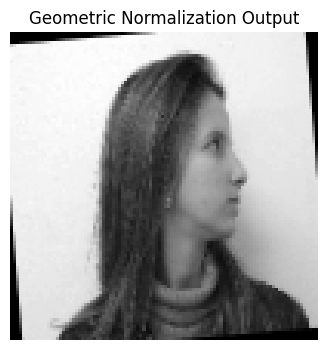

In [17]:
geom_img = geometric_norm(sample)

plt.figure(figsize=(4,4))
plt.imshow(geom_img, cmap='gray')
plt.title("Geometric Normalization Output")
plt.axis("off")
plt.show()

In [18]:
def wavelet_transform(img):

    coeffs = pywt.dwt2(img,'haar')

    LL,(LH,HL,HH) = coeffs

    return cv2.resize(LL,(100,100))

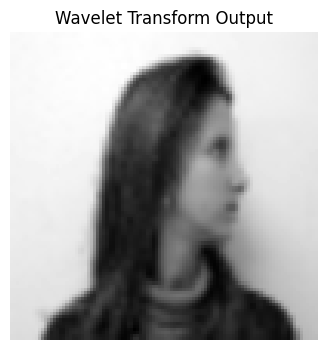

In [19]:
wavelet_img = wavelet_transform(sample)

plt.figure(figsize=(4,4))
plt.imshow(wavelet_img, cmap='gray')
plt.title("Wavelet Transform Output")
plt.axis("off")
plt.show()

In [20]:
def hist_eq(img):

    return cv2.equalizeHist(img)

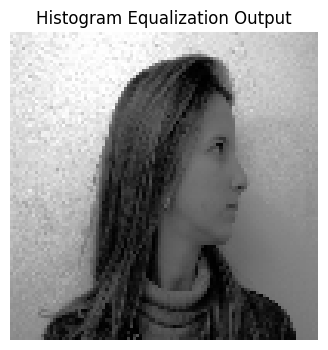

In [21]:
hist_img = hist_eq(sample)

plt.figure(figsize=(4,4))
plt.imshow(hist_img, cmap='gray')
plt.title("Histogram Equalization Output")
plt.axis("off")
plt.show()

In [22]:
methods = {
"Original":lambda x:x,
"Median":median_filter,
"GrayNorm":gray_normalization,
"Geometric":geometric_norm,
"Wavelet":wavelet_transform,
"Histogram":hist_eq,
}

results=[]
accuracies=[]

In [23]:
from keras_facenet import FaceNet
from sklearn.svm import SVC

embedder = FaceNet()

In [24]:
def prepare_for_facenet(images):

    processed = []

    for img in images:

        img = img.astype(np.uint8)

        img = cv2.resize(img,(160,160))

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        processed.append(img)

    return np.array(processed)

In [33]:
results=[]

for name, func in methods.items():

    # Apply preprocessing
    X_train_proc = np.array([func(img) for img in X_train])
    X_test_proc = np.array([func(img) for img in X_test])

    # Convert for FaceNet
    X_train_face = prepare_for_facenet(X_train_proc)
    X_test_face = prepare_for_facenet(X_test_proc)

    # Face embeddings
    train_embeddings = embedder.embeddings(X_train_face)
    test_embeddings = embedder.embeddings(X_test_face)

    # Train classifier
    model = SVC(kernel='linear', C=0.5)
    model.fit(train_embeddings, y_train)

    preds = model.predict(test_embeddings)

    # Classification metrics
    acc = accuracy_score(y_test, preds) * 100
    prec = precision_score(y_test, preds, average='macro') * 100
    rec = recall_score(y_test, preds, average='macro') * 100
    f1 = f1_score(y_test, preds, average='macro') * 100

    # Image quality metrics
    psnr_vals = []
    ssim_vals = []

    for i in range(len(X_test)):
        p, s = image_quality(X_test[i], X_test_proc[i])
        psnr_vals.append(p)
        ssim_vals.append(s)

    psnr_avg = np.mean(psnr_vals)
    ssim_avg = np.mean(ssim_vals)

    results.append([name, acc, prec, rec, f1, psnr_avg, ssim_avg])

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("PSNR:", psnr_avg)
    print("SSIM:", ssim_avg)
    print("---------------------")

44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step


/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


Original
Accuracy: 88.42857142857142
Precision: 94.56208241531132
Recall: 88.42857142857142
F1 Score: 90.44557835376084
PSNR: inf
SSIM: 1.0
---------------------
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step
Median
Accuracy: 84.07142857142857
Precision: 92.42504068035984
Recall: 84.07142857142856
F1 Score: 86.5965859455939
PSNR: 35.069953128711205
SSIM: 0.9572279725807556
---------------------
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step
GrayNorm
Accuracy: 91.5
Precision: 94.38380446509004
Recall: 91.5
F1 Score: 92.20663756178463
PSNR: 15.754723904586346
SSIM: 0.9159372455648728
---------------------
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step
Geometric
Accuracy: 87.57142857142857
Precision: 94.23701840805705
Recall: 87.57142857142857
F1 Score: 89.66727287554494
PSNR: 16.902160161060127
SSIM: 0.7206743406347812
---------------------
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step
44/44 ━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Wavelet
Accuracy: 55.14285714285714
Precision: 64.19730405429459
Recall: 55.14285714285714
F1 Score: 56.63983213633007
PSNR: 10.617560161721379
SSIM: 0.5536962759209756
---------------------
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step
Histogram
Accuracy: 86.64285714285714
Precision: 92.30189618810309
Recall: 86.64285714285714
F1 Score: 88.20725731097248
PSNR: 17.96286940070622
SSIM: 0.751586270131687
---------------------


In [34]:
columns = ["Method","Accuracy","Precision","Recall","F1 Score","PSNR","SSIM"]

df = pd.DataFrame(results, columns=columns)

print(df)

      Method   Accuracy  Precision     Recall   F1 Score       PSNR      SSIM
0   Original  88.428571  94.562082  88.428571  90.445578        inf  1.000000
1     Median  84.071429  92.425041  84.071429  86.596586  35.069953  0.957228
2   GrayNorm  91.500000  94.383804  91.500000  92.206638  15.754724  0.915937
3  Geometric  87.571429  94.237018  87.571429  89.667273  16.902160  0.720674
4    Wavelet  55.142857  64.197304  55.142857  56.639832  10.617560  0.553696
5  Histogram  86.642857  92.301896  86.642857  88.207257  17.962869  0.751586


In [35]:
display(df)

,Method,Accuracy,Precision,Recall,F1 Score,PSNR,SSIM
0,Original,88.428571,94.562082,88.428571,90.445578,inf,1.000000
1,Median,84.071429,92.425041,84.071429,86.596586,35.069953,0.957228
2,GrayNorm,91.500000,94.383804,91.500000,92.206638,15.754724,0.915937
3,Geometric,87.571429,94.237018,87.571429,89.667273,16.902160,0.720674
4,Wavelet,55.142857,64.197304,55.142857,56.639832,10.617560,0.553696
5,Histogram,86.642857,92.301896,86.642857,88.207257,17.962869,0.751586


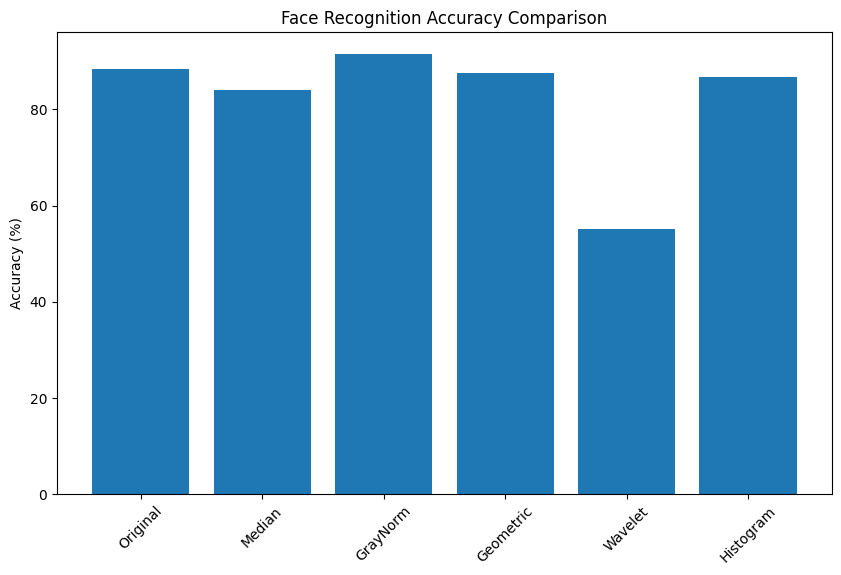

In [31]:
methods_list = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.figure(figsize=(10,6))
plt.bar(methods_list, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Face Recognition Accuracy Comparison")
plt.show()

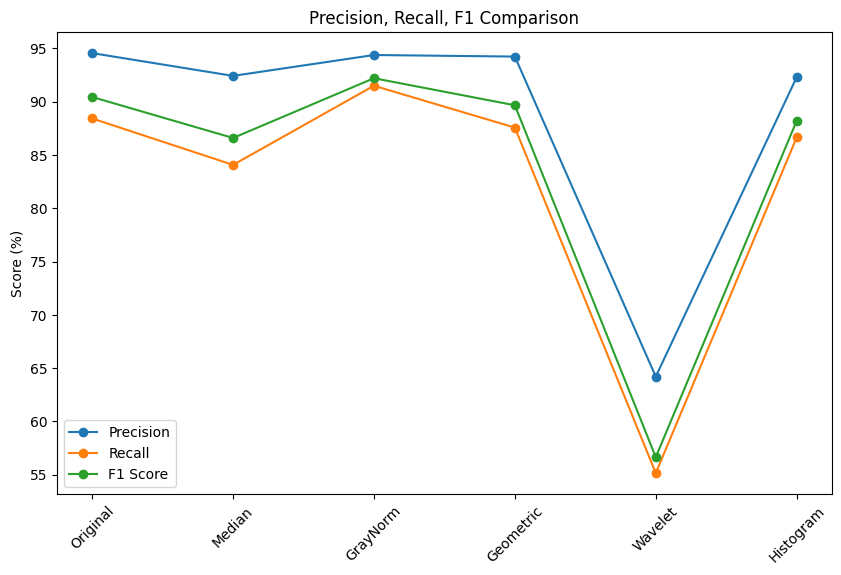

In [36]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["Precision"], marker='o', label="Precision")
plt.plot(df["Method"], df["Recall"], marker='o', label="Recall")
plt.plot(df["Method"], df["F1 Score"], marker='o', label="F1 Score")

plt.xticks(rotation=45)

plt.ylabel("Score (%)")
plt.title("Precision, Recall, F1 Comparison")

plt.legend()

plt.show()

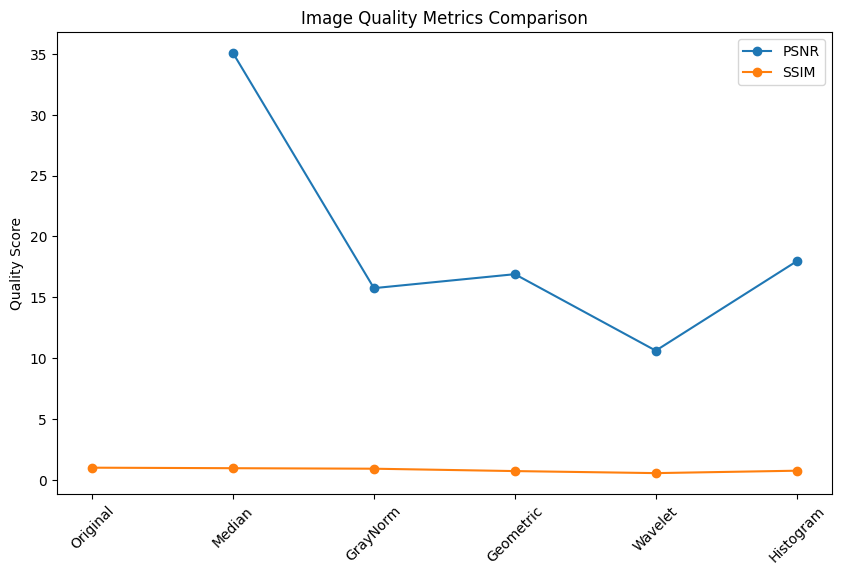

In [37]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["PSNR"], marker='o', label="PSNR")
plt.plot(df["Method"], df["SSIM"], marker='o', label="SSIM")

plt.xticks(rotation=45)

plt.ylabel("Quality Score")
plt.title("Image Quality Metrics Comparison")

plt.legend()

plt.show()

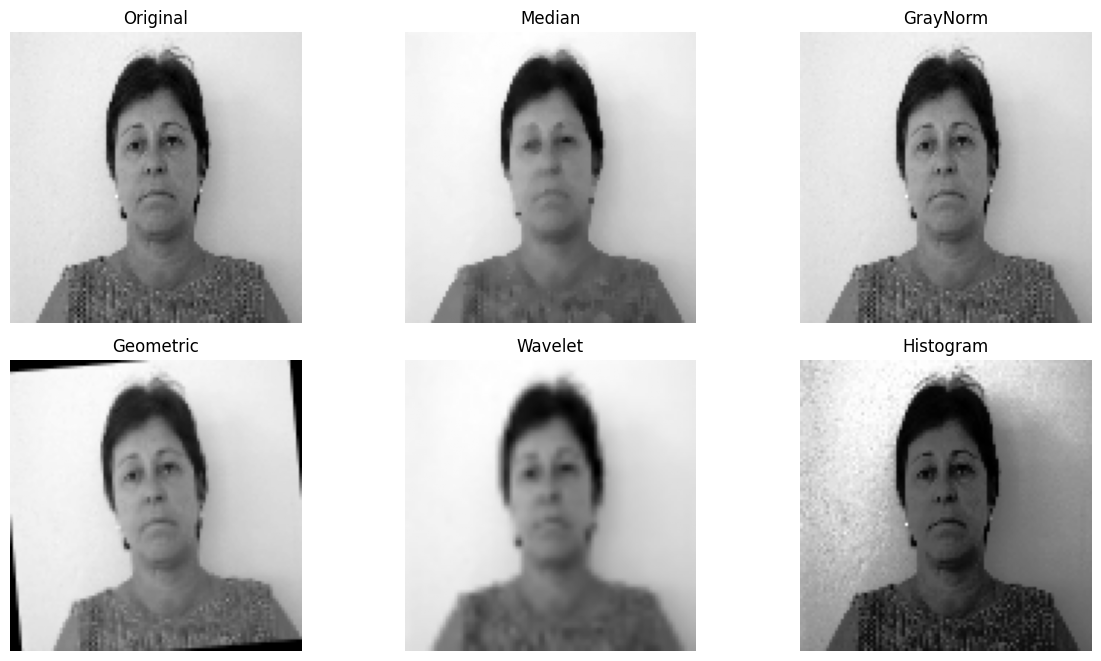

In [39]:
import matplotlib.pyplot as plt

sample = X_test[0]

plt.figure(figsize=(12,10))

# show original
plt.subplot(3,3,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis("off")

i = 2

for name, func in methods.items():

    if name == "Original":
        continue

    processed = func(sample)

    plt.subplot(3,3,i)
    plt.imshow(processed, cmap='gray')
    plt.title(name)
    plt.axis("off")

    i += 1

plt.tight_layout()
plt.show()